In [1]:
# ============================================================
# CELL 0 - Install Forecasting Library
# ============================================================

%pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   --------- ------------------------------ 2.6/11.3 MB 14.0 MB/s eta 0:00:01
   ------------------------------------ --- 10.2/11.3 MB 25.4 MB/s eta 0:00:01
   ---------------------------------------- 11.3/11.3 MB 24.5 MB/s  0:00:00

   ---------------------------------------- 0/4 [patsy]
   ---------------------------------------- 0/4 [patsy]
   -------------------- ------------------- 2/4 [formulaic]
   -------------------- ------------------- 2/4 [formulaic]
   -------------------- ------------------- 2/4 [formulaic]
   ------------------------------ --------- 3/4 [statsmodels]
   ------------------------------ --------- 3/4 [statsmodels]
   ------------------------------ --------- 3/4 [statsmodels]
   ------------------------------ --------- 3/4 [statsmodels]
   ------------------------------ --------- 3/4 [statsmodels]
   -------------


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# ============================================================
# CELL 1 - Prepare Time-Series Data
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

DATA_PATH = "../data/processed/modeling_data.csv"
df = pd.read_csv(DATA_PATH)

df = df.sort_values(["country", "year"]).reset_index(drop=True)

df["co2_lag_1"] = df.groupby("country")["co2"].shift(1)
df["co2_lag_2"] = df.groupby("country")["co2"].shift(2)
df["co2_lag_3"] = df.groupby("country")["co2"].shift(3)

df = df.dropna().copy()

print("=" * 60)
print("TIME-SERIES REGRESSION PREPARATION")
print("=" * 60)
print("Rows after lag creation:", len(df))
print("Countries:", df["country"].nunique())
print("Year range:", df["year"].min(), "-", df["year"].max())
print("Features:", 16)

TIME-SERIES REGRESSION PREPARATION
Rows after lag creation: 1580
Countries: 79
Year range: 2003 - 2022
Features: 16


In [2]:
# ============================================================
# CELL 2 - Chronological Train/Validation/Test Split
# ============================================================

features = [
    "year", "population_co2", "gdp_co2", "primary_energy_consumption_energy",
    "fossil_share_energy", "renewables_share_energy", "renewables_electricity",
    "renewables_share_elec", "solar_share_energy", "wind_share_energy",
    "hydro_share_energy", "gdp_per_capita", "energy_per_capita",
    "co2_lag_1", "co2_lag_2", "co2_lag_3"
]

train = df[df["year"] <= 2016]
val = df[df["year"].between(2017, 2020)]
test = df[df["year"].between(2021, 2024)]

X_train, y_train = train[features], train["co2"]
X_val, y_val = val[features], val["co2"]
X_test, y_test = test[features], test["co2"]

print("=" * 60)
print("CHRONOLOGICAL DATA SPLIT")
print("=" * 60)
print("Training:", X_train.shape, "Years: 2003-2016")
print("Validation:", X_val.shape, "Years: 2017-2020")
print("Testing:", X_test.shape, "Years: 2021-2024")

CHRONOLOGICAL DATA SPLIT
Training: (1106, 16) Years: 2003-2016
Validation: (316, 16) Years: 2017-2020
Testing: (158, 16) Years: 2021-2024


In [3]:
# ============================================================
# CELL 3 - Train Time-Series Regression Model
# ============================================================

print("=" * 60)
print("TIME-SERIES REGRESSION MODEL")
print("=" * 60)

model = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42)
model.fit(X_train, y_train)

val_pred = model.predict(X_val)
test_pred = model.predict(X_test)

print("Gradient Boosting time-series model trained successfully.")

TIME-SERIES REGRESSION MODEL
Gradient Boosting time-series model trained successfully.


TIME-SERIES FORECASTING PERFORMANCE


,Dataset,MAE,RMSE,R²
0,Validation,33.4654,151.5613,0.9868
1,Test,51.5167,240.9586,0.9711



Year-wise Test Results:


,co2,predicted_co2
year,,
2021,34819.88,33991.95
2022,35369.21,34424.63


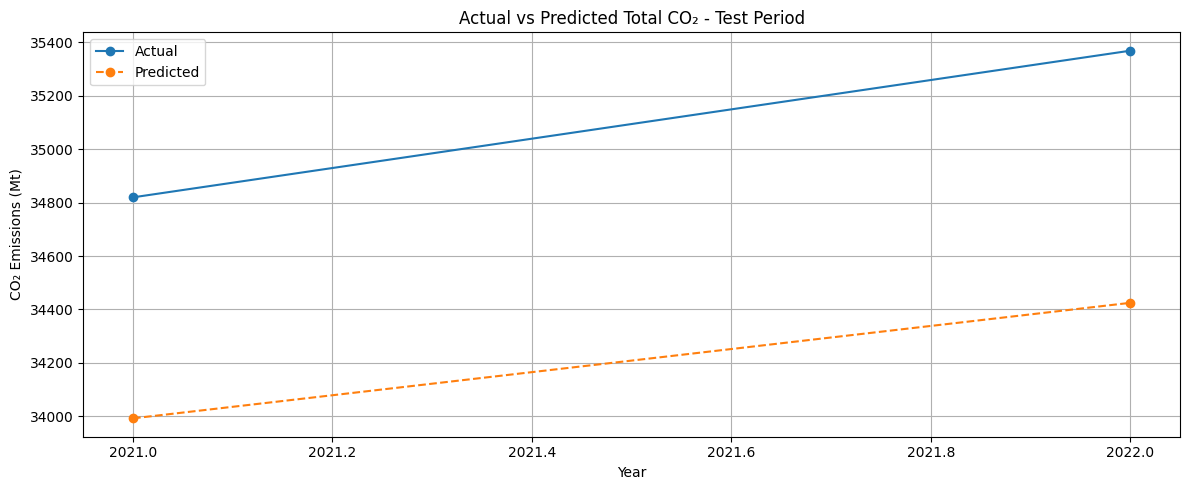

In [6]:
# ============================================================
# CELL 4 - Evaluate Time-Series Forecast
# ============================================================

def calculate_metrics(actual, predicted):
    return [
        mean_absolute_error(actual, predicted),
        np.sqrt(mean_squared_error(actual, predicted)),
        r2_score(actual, predicted)
    ]

val_metrics = calculate_metrics(y_val, val_pred)
test_metrics = calculate_metrics(y_test, test_pred)

results = pd.DataFrame({
    "Dataset": ["Validation", "Test"],
    "MAE": [val_metrics[0], test_metrics[0]],
    "RMSE": [val_metrics[1], test_metrics[1]],
    "R²": [val_metrics[2], test_metrics[2]]
})

print("=" * 60)
print("TIME-SERIES FORECASTING PERFORMANCE")
print("=" * 60)
display(results.round(4))

test_results = test[["year", "co2"]].copy()
test_results["predicted_co2"] = test_pred

yearly_test = test_results.groupby("year")[["co2", "predicted_co2"]].sum()

print("\nYear-wise Test Results:")
display(yearly_test.round(2))

plt.figure(figsize=(12, 5))
plt.plot(yearly_test.index, yearly_test["co2"], marker="o", label="Actual")
plt.plot(yearly_test.index, yearly_test["predicted_co2"], "--o", label="Predicted")
plt.xlabel("Year")
plt.ylabel("CO₂ Emissions (Mt)")
plt.title("Actual vs Predicted Total CO₂ - Test Period")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

FUTURE CO₂ FORECAST
Forecast period: 2023 - 2027

Total predicted CO₂:


,predicted_co2
year,
2023,34451.52
2024,34597.64
2025,35978.45
2026,36263.67
2027,37285.22


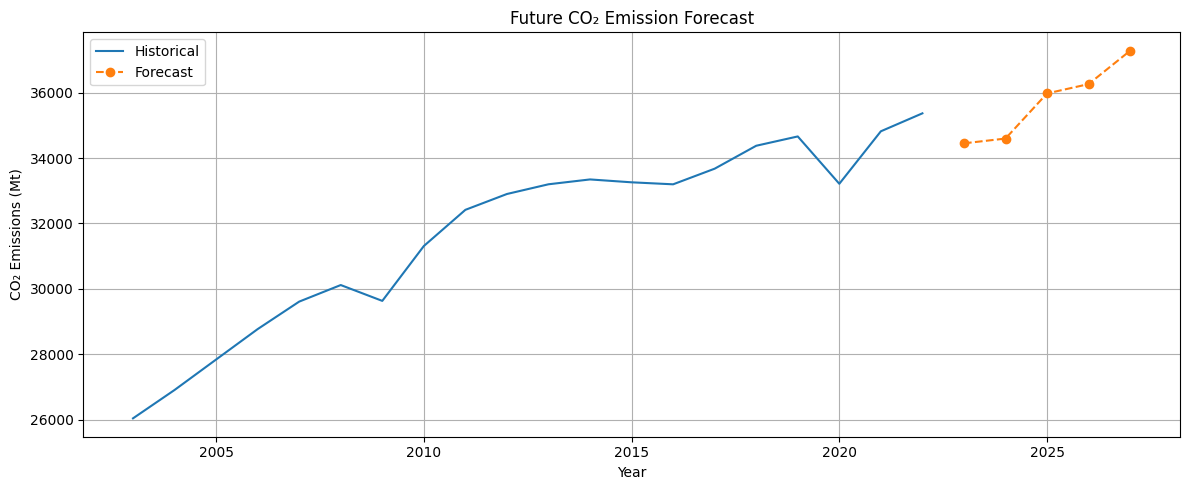

In [7]:
# ============================================================
# CELL 5 - Future CO₂ Forecast
# ============================================================

print("=" * 60)
print("FUTURE CO₂ FORECAST")
print("=" * 60)

latest_year = df["year"].max()
latest = df[df["year"] == latest_year].copy()

future_rows = []

for _, row in latest.iterrows():
    lag1, lag2, lag3 = row["co2"], row["co2_lag_1"], row["co2_lag_2"]

    for year in range(latest_year + 1, latest_year + 6):
        future_row = row[features].copy()
        future_row["year"] = year
        future_row["co2_lag_1"] = lag1
        future_row["co2_lag_2"] = lag2
        future_row["co2_lag_3"] = lag3

        prediction = model.predict(pd.DataFrame([future_row], columns=features))[0]
        future_rows.append([row["country"], year, prediction])

        lag3, lag2, lag1 = lag2, lag1, prediction

forecast_df = pd.DataFrame(future_rows, columns=["country", "year", "predicted_co2"])
yearly_forecast = forecast_df.groupby("year")["predicted_co2"].sum()

print("Forecast period:", latest_year + 1, "-", latest_year + 5)
print("\nTotal predicted CO₂:")
display(yearly_forecast.to_frame("predicted_co2").round(2))

plt.figure(figsize=(12, 5))
historical = df.groupby("year")["co2"].sum()
plt.plot(historical.index, historical.values, label="Historical")
plt.plot(yearly_forecast.index, yearly_forecast.values, "--o", label="Forecast")
plt.xlabel("Year")
plt.ylabel("CO₂ Emissions (Mt)")
plt.title("Future CO₂ Emission Forecast")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()